EXPERIMENT:
SEQ_LEN = 96
PRED_LEN = 48

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import json

In [2]:
X_train = torch.load("../../01_dataset/preprocessed-1/X_train.pt")
y_train = torch.load("../../01_dataset/preprocessed-1/y_train.pt")

X_val = torch.load("../../01_dataset/preprocessed-1/X_val.pt")
y_val = torch.load("../../01_dataset/preprocessed-1/y_val.pt")

X_test = torch.load("../../01_dataset/preprocessed-1/X_test.pt")
y_test = torch.load("../../01_dataset/preprocessed-1/y_test.pt")

print(X_train.shape)

torch.Size([12050, 96, 7])


HYPERPARAMETER

In [3]:
INPUT_DIM = X_train.shape[2]
HIDDEN_DIM = 64
NUM_LAYERS = 2
OUTPUT_DIM = 48

LR = 0.001
EPOCHS = 20
BATCH_SIZE = 32

MODEL

In [4]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, dropout=0.2, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        
        out = out[:, -1, :]
        
        out = self.fc(out)
        return out

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, OUTPUT_DIM).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [6]:
num_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", num_params)

Total parameters: 55088


TRAINING

In [7]:
history = []

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for i in range(0, len(X_train), BATCH_SIZE):
        X_batch = X_train[i:i+BATCH_SIZE].to(device)
        y_batch = y_train[i:i+BATCH_SIZE].to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(X_train)

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        outputs = model(X_val.to(device))
        val_loss = criterion(outputs, y_val.to(device)).item()

    history.append([epoch, train_loss, val_loss])

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.4f} seconds")

Epoch 1, Train Loss: 0.0187, Val Loss: 0.5958
Epoch 2, Train Loss: 0.0256, Val Loss: 0.7028
Epoch 3, Train Loss: 0.0249, Val Loss: 1.1324
Epoch 4, Train Loss: 0.0148, Val Loss: 0.3558
Epoch 5, Train Loss: 0.0295, Val Loss: 1.1549
Epoch 6, Train Loss: 0.0335, Val Loss: 1.7747
Epoch 7, Train Loss: 0.0321, Val Loss: 1.9441
Epoch 8, Train Loss: 0.0311, Val Loss: 1.9053
Epoch 9, Train Loss: 0.0180, Val Loss: 0.4631
Epoch 10, Train Loss: 0.0231, Val Loss: 1.3435
Epoch 11, Train Loss: 0.0116, Val Loss: 0.3487
Epoch 12, Train Loss: 0.0114, Val Loss: 0.3316
Epoch 13, Train Loss: 0.0156, Val Loss: 0.6131
Epoch 14, Train Loss: 0.0124, Val Loss: 0.3674
Epoch 15, Train Loss: 0.0121, Val Loss: 0.2787
Epoch 16, Train Loss: 0.0082, Val Loss: 0.2682
Epoch 17, Train Loss: 0.0066, Val Loss: 0.2715
Epoch 18, Train Loss: 0.0056, Val Loss: 0.2408
Epoch 19, Train Loss: 0.0051, Val Loss: 0.2145
Epoch 20, Train Loss: 0.0050, Val Loss: 0.2034
Training time: 17.6459 seconds


In [8]:
history_df = pd.DataFrame(history, columns=["epoch", "train_loss", "val_loss"])
history_df.to_csv("result-1/lstm_history.csv", index=False)

In [9]:
model.eval()

with torch.no_grad():
    preds = model(X_test.to(device)).cpu().numpy()
    true = y_test.numpy()

mae = np.mean(np.abs(preds - true))
mse = np.mean((preds - true)**2)
rmse = np.sqrt(mse)

print(mae, mse, rmse)

0.20967034 0.073060066 0.27029625


In [10]:
metrics_df = pd.DataFrame([[mae, mse, rmse]], columns=["MAE", "MSE", "RMSE"])
metrics_df.to_csv("result-1/lstm_metrics.csv", index=False)

In [11]:
pred_flat = preds.flatten()
true_flat = true.flatten()

pred_df = pd.DataFrame({
    "y_true": true_flat,
    "y_pred": pred_flat
})

pred_df.to_csv("result-1/lstm_predictions.csv", index=False)

In [12]:
config = {
    "model": "LSTM",
    "seq_len": 96,
    "pred_len": 48,
    "input_dim": INPUT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "epochs": EPOCHS,
    "num_parameters": num_params,
    "training_time_seconds": training_time
}

with open("result-1/lstm_config.json", "w") as f:
    json.dump(config, f, indent=4)

PLOT

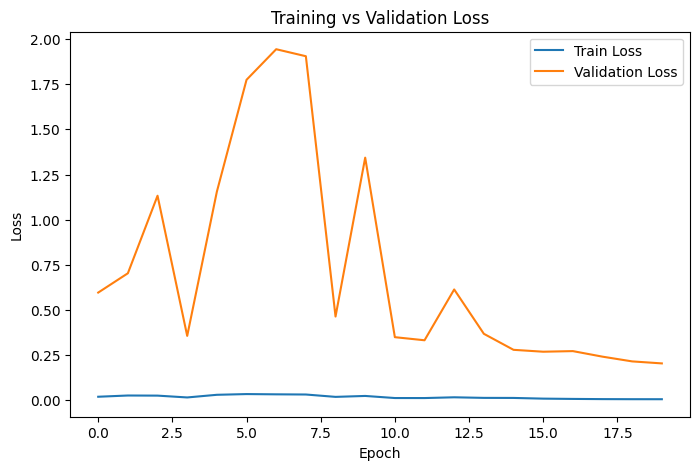

In [13]:
history = pd.read_csv("result-1/lstm_history.csv")

plt.figure(figsize=(8,5))

plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

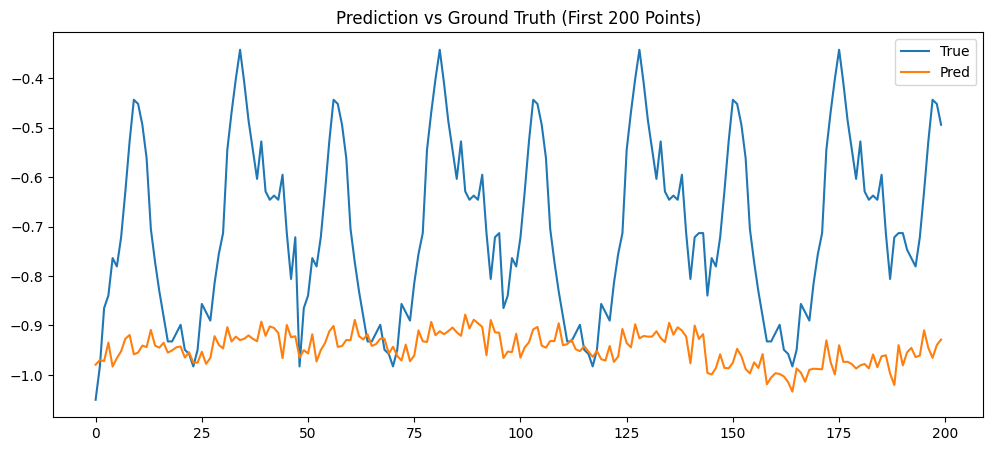

In [14]:
pred_df = pd.read_csv("result-1/lstm_predictions.csv")

y_true = pred_df["y_true"].values
y_pred = pred_df["y_pred"].values

plt.figure(figsize=(12,5))

plt.plot(y_true[:200], label="True")
plt.plot(y_pred[:200], label="Pred")

plt.title("Prediction vs Ground Truth (First 200 Points)")
plt.legend()

plt.show()

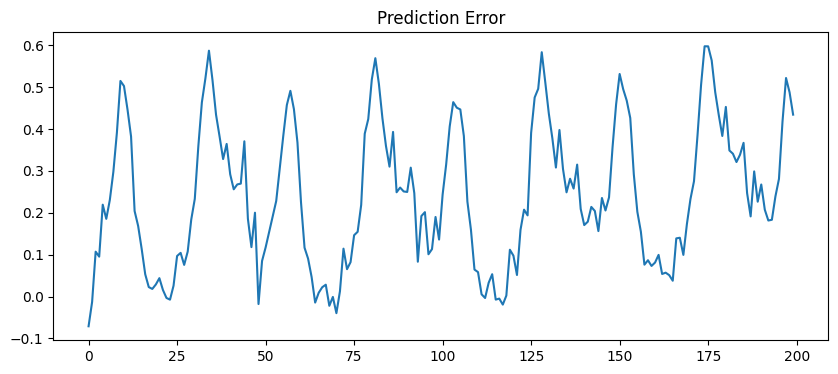

In [15]:
error = y_true - y_pred

plt.figure(figsize=(10,4))
plt.plot(error[:200])
plt.title("Prediction Error")
plt.show()